# axon CIFAR-10

3-layer MLP — `Linear(3072, 256) → Sigmoid → Linear(256, 128) → Sigmoid → Linear(128, 10)` + CrossEntropyLoss + SGD(lr=0.1). ~45% test accuracy (20 epoch).

CIFAR-10 은 spatial 구조가 분류에 결정적이라 MLP 는 ~50% 가 천장. CNN 도입 (v2 이후) 으로 80%+ 도달이 다음 마일스톤.

In [1]:
import os
import pickle
import tarfile
import time
import urllib.request
from collections.abc import Iterator

import numpy as np
from numpy.typing import NDArray
from tqdm.notebook import tqdm

import axon
from axon import Constant, Node, Var, net
from axon.optim import SGD

## 데이터 로딩

In [2]:
CIFAR_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
CACHE_DIR = os.path.expanduser("~/.cache/axon")
TAR_PATH = os.path.join(CACHE_DIR, "cifar-10-python.tar.gz")
EXTRACT_DIR = os.path.join(CACHE_DIR, "cifar-10-batches-py")

CLASSES = (
  "airplane", "automobile", "bird", "cat", "deer",
  "dog", "frog", "horse", "ship", "truck",
)

os.makedirs(CACHE_DIR, exist_ok=True)
if not os.path.isdir(EXTRACT_DIR):
  if not os.path.isfile(TAR_PATH):
    print("downloading CIFAR-10 (~170MB) ...")
    urllib.request.urlretrieve(CIFAR_URL, TAR_PATH)
  print("extracting ...")
  with tarfile.open(TAR_PATH) as tar:
    tar.extractall(CACHE_DIR)


def load_batch(path: str) -> tuple[NDArray[np.uint8], NDArray[np.int64]]:
  with open(path, "rb") as f:
    d = pickle.load(f, encoding="bytes")
  return d[b"data"], np.array(d[b"labels"], dtype=np.int64)


xs, ts = [], []
for i in range(1, 6):
  x, t = load_batch(os.path.join(EXTRACT_DIR, f"data_batch_{i}"))
  xs.append(x); ts.append(t)
X_train = np.concatenate(xs).astype(np.float32) / 255.0
T_train = np.concatenate(ts)
X_test_u8, T_test = load_batch(os.path.join(EXTRACT_DIR, "test_batch"))
X_test = X_test_u8.astype(np.float32) / 255.0

print(f"X_train: {X_train.shape}, T_train: {T_train.shape}")
print(f"X_test:  {X_test.shape}, T_test:  {T_test.shape}")
print(f"class distribution train: {np.bincount(T_train)}")

/var/folders/sf/nvt_gtqx6c970wj9fj9sf9h00000gn/T/ipykernel_28186/1871341736.py:23: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding="bytes")


X_train: (50000, 3072), T_train: (50000,)
X_test:  (10000, 3072), T_test:  (10000,)
class distribution train: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


## 샘플 보기

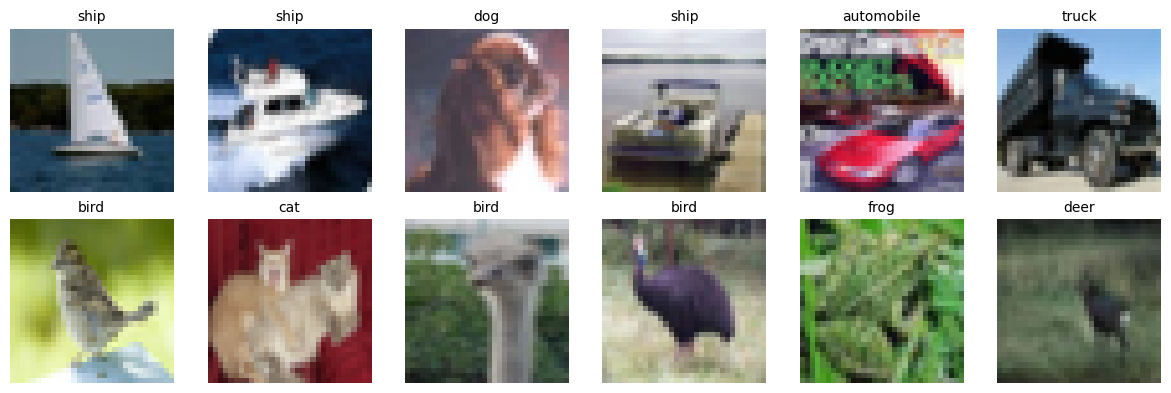

In [3]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
sample_idx = rng.choice(len(X_train), size=12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, i in zip(axes.ravel(), sample_idx):
  img = X_train[i].reshape(3, 32, 32).transpose(1, 2, 0)
  ax.imshow(img)
  ax.set_title(CLASSES[T_train[i]], fontsize=10)
  ax.axis("off")
plt.tight_layout()
plt.show()

## 모델

In [ ]:
BATCH_SIZE = 128
HIDDEN1 = 256
HIDDEN2 = 128
EPOCHS = 20
LR = 0.1


class MLP(net.Net):
  optimizer = SGD(lr=LR)

  def __init__(self):
    self.fc1 = net.Linear(3072, HIDDEN1, bias=False)
    self.act1 = net.Sigmoid()
    self.fc2 = net.Linear(HIDDEN1, HIDDEN2, bias=False)
    self.act2 = net.Sigmoid()
    self.fc3 = net.Linear(HIDDEN2, 10, bias=False)

  def forward(self, x: Node) -> Var:
    x = self.fc1.forward(x)
    x = self.act1.forward(x)
    x = self.fc2.forward(x)
    x = self.act2.forward(x)
    return self.fc3.forward(x)


axon.set_backend("numpy")
np.random.seed(0)

model = MLP()
loss_fn = net.CrossEntropyLoss()

n_params = sum(p._data.size for p in model.parameters())
print(f"params: {n_params:,}, lr={LR}, hidden=({HIDDEN1}, {HIDDEN2}), batch={BATCH_SIZE}")

## 학습 / 평가

In [ ]:
def iterate_batches(
  x: NDArray[np.float32],
  t: NDArray[np.int64],
  batch_size: int,
  *,
  shuffle: bool,
) -> Iterator[tuple[NDArray[np.float32], NDArray[np.int64]]]:
  n = x.shape[0]
  idx = np.random.permutation(n) if shuffle else np.arange(n)
  for start in range(0, n, batch_size):
    b = idx[start : start + batch_size]
    yield x[b], t[b]


train_steps = (X_train.shape[0] + BATCH_SIZE - 1) // BATCH_SIZE
test_steps = (X_test.shape[0] + 256 - 1) // 256

for epoch in range(1, EPOCHS + 1):
  t0 = time.time()

  train_loss = 0.0
  train_correct = 0
  for x_b, t_b in tqdm(
    iterate_batches(X_train, T_train, BATCH_SIZE, shuffle=True),
    total=train_steps,
    leave=False,
  ):
    logits = model.forward(Constant(x_b))
    loss = loss_fn.forward(logits, t_b)
    loss.backward()
    loss.optimize()

    train_loss += float(loss.as_numpy())
    train_correct += int((np.argmax(logits.as_numpy(), axis=1) == t_b).sum())

  test_loss = 0.0
  test_correct = 0
  for x_b, t_b in tqdm(
    iterate_batches(X_test, T_test, 256, shuffle=False),
    total=test_steps,
    leave=False,
  ):
    logits = model.forward(Constant(x_b))
    loss = loss_fn.forward(logits, t_b)
    test_loss += float(loss.as_numpy())
    test_correct += int((np.argmax(logits.as_numpy(), axis=1) == t_b).sum())

  print(
    f"epoch {epoch:2d}/{EPOCHS} | "
    f"train loss={train_loss / train_steps:.4f} acc={train_correct / X_train.shape[0]:.4f} | "
    f"test loss={test_loss / test_steps:.4f} acc={test_correct / X_test.shape[0]:.4f} | "
    f"{time.time() - t0:.1f}s"
  )

## 예측 샘플

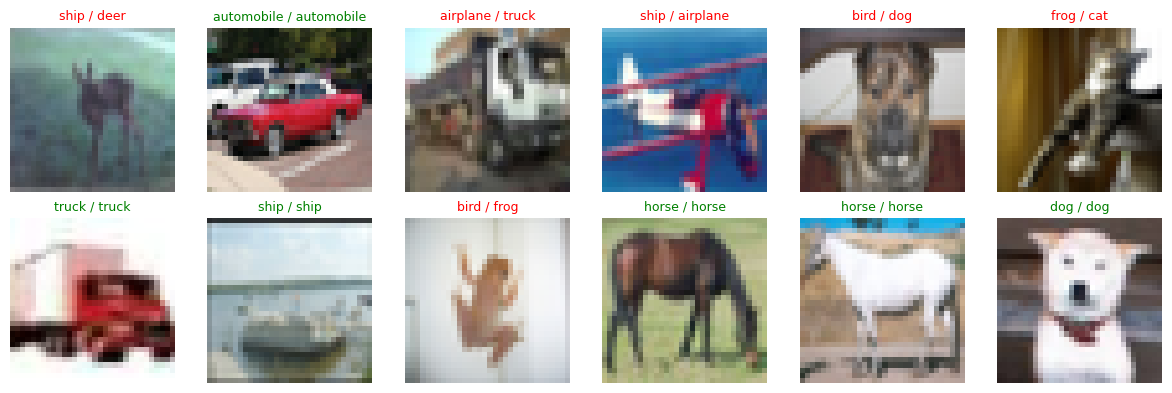

In [6]:
rng = np.random.default_rng(7)
sample_idx = rng.choice(len(X_test), size=12, replace=False)
x_sample = X_test[sample_idx]
t_sample = T_test[sample_idx]
pred = np.argmax(model.forward(Constant(x_sample)).as_numpy(), axis=1)

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, img_flat, p, t in zip(axes.ravel(), x_sample, pred, t_sample):
  img = img_flat.reshape(3, 32, 32).transpose(1, 2, 0)
  ax.imshow(img)
  color = "green" if p == t else "red"
  ax.set_title(f"{CLASSES[p]} / {CLASSES[t]}", color=color, fontsize=9)
  ax.axis("off")
plt.tight_layout()
plt.show()